In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("bethesda-classification")

### Служебная информация об эксперименте

В этой ячейке фиксируется служебная информация для воспроизводимости эксперимента: имя участника, название задачи, дата запуска и SHA текущего Git-коммита.

In [16]:
import subprocess
from datetime import datetime

# Основная информация об эксперименте
participant = "Savely"
task_name = "bethesda-classification"

# Автоматически получаем SHA текущего Git-коммита
git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()

# Сохраняем текущую дату запуска эксперимента
run_date = datetime.now().strftime("%Y-%m-%d")

print("Participant:", participant)
print("Task:", task_name)
print("Date:", run_date)
print("Git commit:", git_commit)

Participant: Savely
Task: bethesda-classification
Date: 2026-10-10
Git commit: d5e080e07c40dff53a33982edd52f2eb6aa4a092


### Версия датасета

Для воспроизводимости экспериментов используется SHA256-хеш файла `dataset_first.csv`.

Логика вычисления хеша вынесена в общий модуль `src/common/dataset_versioning.py`,
чтобы одна и та же реализация использовалась при архивировании датасетов и в экспериментах классификации.

При сохранении версии датасета отдельная копия помещается в каталог
`data/processed/versions`, а первые 12 символов SHA256 добавляются к имени файла.

В MLflow будет сохраняться полный SHA256-хеш, что позволяет однозначно связать
каждый запуск модели с конкретной версией данных.

In [10]:
from pathlib import Path

from src.common.dataset_versioning import calculate_sha256

# Определяем корень проекта
PROJECT_ROOT = Path.cwd()

# Если Jupyter запущен из папки notebooks/classification,
# поднимаемся до корня проекта
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parents[1]

# Путь к основному датасету классификации
dataset_path = PROJECT_ROOT / "data" / "processed" / "dataset_first.csv"

# Вычисляем SHA256 текущей версии датасета
dataset_hash = calculate_sha256(dataset_path)

# Короткая версия используется только для удобного отображения
dataset_version = dataset_hash[:12]

print("Dataset:", dataset_path.name)
print("Dataset version:", dataset_version)
print("Full SHA256:", dataset_hash)

Dataset: dataset_first.csv
Dataset version: b5825a9b4570
Full SHA256: b5825a9b457023d0c180c5ebc2ad081d183bd30c4ea1d593031522c4e50730e9


 ## Загрузка и первичная проверка датасета

Загрузим текущую версию `dataset_first.csv`, для которой ранее был вычислен SHA256-хеш.

На этом этапе проверим размер датасета, названия столбцов и первые строки данных.
Это позволяет убедиться, что файл корректно загружен и готов к дальнейшему анализу.

Модель пока не обучается, поэтому отдельный запуск MLflow на этом этапе не создаётся.

In [ ]:
import pandas as pd

# Проверяем, что файл датасета существует
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Датасет не найден: {dataset_path}"
    )

# Загружаем подготовленный датасет
df = pd.read_csv(dataset_path, sep=";")

print("Путь к датасету:", dataset_path)
print("Размер датасета:", df.shape)
print("Столбцы:", df.columns.tolist())

df.head()

## Проверка структуры и качества данных

Проверим названия столбцов, количество пропущенных значений
и распределение объектов по классам Bethesda.
Это необходимо перед разделением данных на обучающую и тестовую выборки.

In [13]:
print("Столбцы:")
print(df.columns.tolist())

print("\nПропущенные значения:")
print(df.isna().sum())

print("\nКоличество объектов каждого класса Bethesda:")
print(df["bethesda"].value_counts().sort_index())

print("\nДоля каждого класса:")
print(df["bethesda"].value_counts(normalize=True).sort_index().round(4))

Столбцы:
['case_id', 'description', 'conclusion', 'bethesda']

Пропущенные значения:
case_id        0
description    0
conclusion     0
bethesda       0
dtype: int64

Количество объектов каждого класса Bethesda:
bethesda
I       576
II     3814
III     287
IV      549
V       166
VI      195
Name: count, dtype: int64

Доля каждого класса:
bethesda
I      0.1031
II     0.6827
III    0.0514
IV     0.0983
V      0.0297
VI     0.0349
Name: proportion, dtype: float64


Всего 5587 строк, пропусков нет, целевая переменная заполнена полностью. Но классы заметно несбалансированы: Bethesda II занимает 68.27%, а самые редкие V и VI - около 3% каждая.

## Проверка дубликатов

Перед разделением данных на обучающую и тестовую выборки проверим наличие
повторяющихся идентификаторов и текстов `description`.

Особенно важно исключить ситуацию, когда одинаковые описания попадают
одновременно в train и test, поскольку это может привести к утечке данных
и завышенной оценке качества модели.

Поле `conclusion` не используется как вход модели. Для классификации
используется только `description`, а `bethesda` является целевой переменной.

In [14]:
# Проверяем уникальность идентификаторов случаев
duplicate_case_ids = df["case_id"].duplicated().sum()

# Проверяем полные дубликаты строк
duplicate_rows = df.duplicated().sum()

# Проверяем повторяющиеся тексты description
duplicate_descriptions = df["description"].duplicated().sum()

print("Дубликаты case_id:", duplicate_case_ids)
print("Полные дубликаты строк:", duplicate_rows)
print("Повторяющиеся description:", duplicate_descriptions)

# Проверяем, встречается ли один и тот же description
# с разными категориями Bethesda
description_bethesda_counts = (
    df.groupby("description")["bethesda"]
    .nunique()
)

conflicting_descriptions = description_bethesda_counts[
    description_bethesda_counts > 1
]

print(
    "Description с разными категориями Bethesda:",
    len(conflicting_descriptions)
)

Дубликаты case_id: 0
Полные дубликаты строк: 0
Повторяющиеся description: 0
Description с разными категориями Bethesda: 0


## Разделение данных на обучающую и тестовую выборки

В качестве входного признака модели используется только поле `description`,
а целевой переменной является категория `bethesda`.

Данные разделяются на обучающую и тестовую выборки в отношении 80/20.
Используется стратифицированное разделение, чтобы сохранить исходное
соотношение классов Bethesda в обеих выборках.

Параметр `random_state=42` фиксирует случайное разделение и делает эксперимент
воспроизводимым.

TF-IDF будет обучаться только на обучающей выборке после разделения данных,
чтобы исключить утечку информации из test в train.

In [15]:
from sklearn.model_selection import train_test_split

# В качестве входа модели используем только текст description
X = df["description"]

# Целевая переменная - категория Bethesda
y = df["bethesda"]

# Делим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Размер всей выборки:", len(X))
print("Размер train:", len(X_train))
print("Размер test:", len(X_test))

print("\nРаспределение классов в train:")
print(y_train.value_counts().sort_index())

print("\nРаспределение классов в test:")
print(y_test.value_counts().sort_index())

Размер всей выборки: 5587
Размер train: 4469
Размер test: 1118

Распределение классов в train:
bethesda
I       461
II     3051
III     229
IV      439
V       133
VI      156
Name: count, dtype: int64

Распределение классов в test:
bethesda
I      115
II     763
III     58
IV     110
V       33
VI      39
Name: count, dtype: int64


## Первый baseline: TF-IDF + Logistic Regression

В качестве первой модели используется базовый подход к классификации текстов:
TF-IDF преобразует тексты `description` в числовое представление, после чего
Logistic Regression выполняет классификацию по категориям Bethesda.

Первый эксперимент проводится с простыми параметрами без балансировки классов
и без использования биграмм. Его результат будет использоваться как базовая
точка для сравнения следующих запусков.

Используемые параметры:

- `ngram_range=(1, 1)` - используются только отдельные слова;
- `min_df=2` - исключаются слова, встретившиеся только в одном документе;
- `lowercase=True` - текст приводится к нижнему регистру;
- `class_weight=None` - балансировка классов не используется;
- `max_iter=1000` - увеличено максимальное число итераций для сходимости;
- `random_state=42` - фиксируется для воспроизводимости.

In [17]:
# Параметры TF-IDF для первого baseline
tfidf_params = {
    "ngram_range": (1, 1),
    "min_df": 2,
    "lowercase": True,
}

# Параметры Logistic Regression
logreg_params = {
    "max_iter": 1000,
    "random_state": 42,
    "class_weight": None,
}

print("TF-IDF parameters:")
print(tfidf_params)

print("\nLogistic Regression parameters:")
print(logreg_params)

TF-IDF parameters:
{'ngram_range': (1, 1), 'min_df': 2, 'lowercase': True}

Logistic Regression parameters:
{'max_iter': 1000, 'random_state': 42, 'class_weight': None}


In [19]:
# Быстрая проверка
print("Git commit:", git_commit)
print("Dataset SHA256:", dataset_hash)
print(mlflow.get_tracking_uri())

Git commit: d5e080e07c40dff53a33982edd52f2eb6aa4a092
Dataset SHA256: b5825a9b457023d0c180c5ebc2ad081d183bd30c4ea1d593031522c4e50730e9
http://127.0.0.1:5000


## Запуск первого эксперимента в MLflow

Первый baseline обучается как единый `Pipeline`, состоящий из:

1. `TfidfVectorizer` - преобразование текста `description` в TF-IDF-признаки;
2. `LogisticRegression` - многоклассовая классификация Bethesda.

В рамках одного MLflow run сохраняются:

- участник и название задачи;
- дата запуска;
- Git commit;
- SHA256 версии датасета;
- название и параметры модели;
- размеры train и test;
- `macro-F1`;
- `balanced accuracy`;
- recall каждого класса Bethesda;
- confusion matrix;
- обученный Pipeline.

Использование `Pipeline` позволяет сохранить TF-IDF и классификатор как одну модель,
которая в дальнейшем сможет принимать исходный текст без отдельной ручной векторизации.

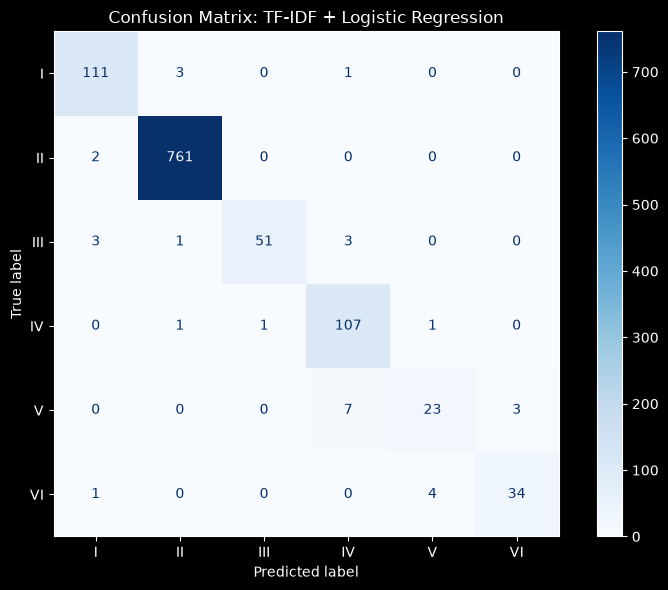

MLflow run ID: 8a5ba86b70f1414c80b5ae650115cf0f
🏃 View run tfidf_logreg_baseline at: http://127.0.0.1:5000/#/experiments/1/runs/8a5ba86b70f1414c80b5ae650115cf0f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [20]:
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    recall_score,
    ConfusionMatrixDisplay,
)


# Создаём единый Pipeline: текст -> TF-IDF -> Logistic Regression
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(**tfidf_params),
    ),
    (
        "logreg",
        LogisticRegression(**logreg_params),
    ),
])


# Запускаем первый эксперимент MLflow
with mlflow.start_run(run_name="tfidf_logreg_baseline") as run:

    # Сохраняем общую информацию об эксперименте
    mlflow.log_params({
        "participant": participant,
        "task_name": task_name,
        "run_date": str(run_date),
        "git_commit": git_commit,
        "dataset_version": dataset_hash,
        "model_name": "TF-IDF + Logistic Regression",
        "train_size": len(X_train),
        "test_size": len(X_test),
        "test_size_ratio": 0.2,
        "split_random_state": 42,
    })

    # Сохраняем параметры TF-IDF
    mlflow.log_params({
        "tfidf_ngram_range": str(tfidf_params["ngram_range"]),
        "tfidf_min_df": tfidf_params["min_df"],
        "tfidf_lowercase": tfidf_params["lowercase"],
    })

    # Сохраняем параметры Logistic Regression
    mlflow.log_params({
        "logreg_max_iter": logreg_params["max_iter"],
        "logreg_random_state": logreg_params["random_state"],
        "logreg_class_weight": str(logreg_params["class_weight"]),
    })

    # Обучаем Pipeline только на обучающей выборке
    model.fit(X_train, y_train)

    # Получаем предсказания на тестовой выборке
    y_pred = model.predict(X_test)

    # Считаем основные метрики
    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred,
    )

    # Фиксируем порядок классов Bethesda
    classes = ["I", "II", "III", "IV", "V", "VI"]

    # Считаем recall отдельно для каждого класса
    recall_per_class = recall_score(
        y_test,
        y_pred,
        labels=classes,
        average=None,
        zero_division=0,
    )

    # Сохраняем основные метрики в MLflow
    mlflow.log_metric("macro_f1", macro_f1)
    mlflow.log_metric("balanced_accuracy", balanced_acc)

    # Сохраняем recall каждого класса
    for class_name, recall_value in zip(classes, recall_per_class):
        mlflow.log_metric(
            f"recall_bethesda_{class_name}",
            recall_value,
        )

    # Строим confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=classes,
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    ax.set_title("Confusion Matrix: TF-IDF + Logistic Regression")

    plt.tight_layout()

    # Сохраняем confusion matrix как артефакт MLflow
    mlflow.log_figure(
        fig,
        "confusion_matrix.png",
    )

    plt.show()
    plt.close(fig)

    # Сохраняем весь обученный Pipeline:
    # TF-IDF + Logistic Regression
    mlflow.sklearn.log_model(
        sk_model=model,
        name="model",
    )

    print("MLflow run ID:", run.info.run_id)

In [21]:
print(f"Macro-F1: {macro_f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

print("\nRecall каждого класса:")

for class_name, recall_value in zip(classes, recall_per_class):
    print(f"Bethesda {class_name}: {recall_value:.4f}")

Macro-F1: 0.9112
Balanced accuracy: 0.8972

Recall каждого класса:
Bethesda I: 0.9652
Bethesda II: 0.9974
Bethesda III: 0.8793
Bethesda IV: 0.9727
Bethesda V: 0.6970
Bethesda VI: 0.8718


## Анализ результатов первого baseline

Первая модель `TF-IDF + Logistic Regression` показала достаточно высокое качество:

- `macro-F1 = 0.9112`;
- `balanced accuracy = 0.8972`.

Recall для большинства классов также оказался высоким. Наиболее уверенно модель распознаёт
Bethesda I, II и IV. Наименьший recall получен для Bethesda V - `0.6970`.

Высокое качество baseline может объясняться несколькими факторами.

Во-первых, перед обучением использовался существенно очищенный датасет. Из исходных данных
были исключены записи, требующие дополнительной проверки, а также часть некорректных и
подозрительно коротких описаний. В результате модель обучается на более однородных и
качественно размеченных примерах.

Во-вторых, цитологические описания могут содержать характерную медицинскую лексику,
частота и сочетание которой отличаются между категориями Bethesda. TF-IDF хорошо подходит
для выявления подобных различий, поскольку увеличивает вес информативных терминов и
уменьшает влияние слов, часто встречающихся во всём корпусе.

В-третьих, даже простая линейная модель может хорошо работать в пространстве TF-IDF,
если классы достаточно хорошо разделяются по используемой терминологии. Logistic Regression
в процессе обучения подбирает веса текстовых признаков для каждого класса и на их основе
определяет наиболее вероятную категорию для нового описания.

При этом результаты нельзя считать одинаково высокими для всех классов. Наиболее заметная
проблема наблюдается для Bethesda V: из 33 тестовых объектов правильно классифицированы 23,
при этом часть объектов была отнесена к Bethesda IV и VI. Это указывает на то, что тексты
этих категорий могут иметь более похожие признаки.

Кроме того, датасет остаётся несбалансированным: Bethesda II составляет большую часть
наблюдений, тогда как классы V и VI представлены значительно слабее. Поэтому дальнейшие
эксперименты должны оценивать не только общее качество модели, но и изменение recall
редких классов.

Таким образом, первый эксперимент показывает, что даже базовая комбинация
`TF-IDF + Logistic Regression` хорошо выделяет закономерности в очищенных текстовых данных.
Полученный результат используется как baseline для сравнения с последующими вариантами модели.